In [ ]:
#AI-Generated - Unsupervised model

from nsdf_dark_matter.idx import load_all_data
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# 1. Load Data
home_directory = Path.home()
cdms = load_all_data(str(home_directory)+'/idx/07180827_0000_F0002')
detector_ids = cdms.get_detector_ids()

# 2. Feature Extraction Setup
features = []
valid_detector_ids = []

# Process the first 500 detectors to build a quick test dataset
for i in range(5000): 
    try:
        channel_data = cdms.get_detector_channels(detector_ids[i])
        
        # Baseline subtraction using the last 100 points
        trace_0 = channel_data[0] - np.mean(channel_data[0][-100:])
        trace_1 = channel_data[1] - np.mean(channel_data[1][-100:])
        
        # Feature A: Variance (detects localized spikes)
        variance = np.var(trace_0)
        
        # Feature B: Slope of the trendline (detects rising/falling baseline)
        x_axis = np.arange(len(trace_0))
        slope, _ = np.polyfit(x_axis, trace_0, 1)
        
        # Feature C: Cross-channel correlation (detects shape uniformity)
        # corrcoef returns a 2x2 matrix; we take the off-diagonal value
        correlation = np.corrcoef(trace_0, trace_1)[0, 1] 
        
        features.append([variance, slope, correlation])
        valid_detector_ids.append(detector_ids[i])
        
    except (IndexError, ValueError):
        # Skips events with missing channels or mismatched array sizes
        continue

# Convert to a 2D NumPy array (Rows: Events, Columns: Features)
X = np.array(features)

# 3. Machine Learning Pipeline
# Create a pipeline that scales the data, then runs the Isolation Forest
# contamination=0.05 assumes roughly 5% of your events are anomalies
model = make_pipeline(StandardScaler(), IsolationForest(random_state=42))

#, contamination=0.05             put that back in front of random_state=42 if want hardcoded # of anomalies    

# Fit the model and predict labels (-1 for anomaly, 1 for normal noise)
labels = model.fit_predict(X)

# 4. Review Results
# Find the indices in our array where the label is -1 (anomaly)
anomaly_indices = np.where(labels == -1)[0]

print(f"Total events analyzed: {len(X)}")
print(f"Anomalies found: {len(anomaly_indices)}")

# Plot the first flagged anomaly to see what the machine caught
if len(anomaly_indices) > 0:
    first_anomaly_idx = anomaly_indices[2]
    bad_detector_id = valid_detector_ids[first_anomaly_idx]
    
    print(f"Plotting anomaly from detector ID: {bad_detector_id}")
    bad_data = cdms.get_detector_channels(bad_detector_id)
    
    plt.plot(bad_data[0] - np.mean(bad_data[0][-100:]), label='Channel 0')
    plt.plot(bad_data[1] - np.mean(bad_data[1][-100:]), label='Channel 1')
    plt.title(f"Flagged Anomaly (Detector {bad_detector_id})")
    plt.legend()
    plt.show()

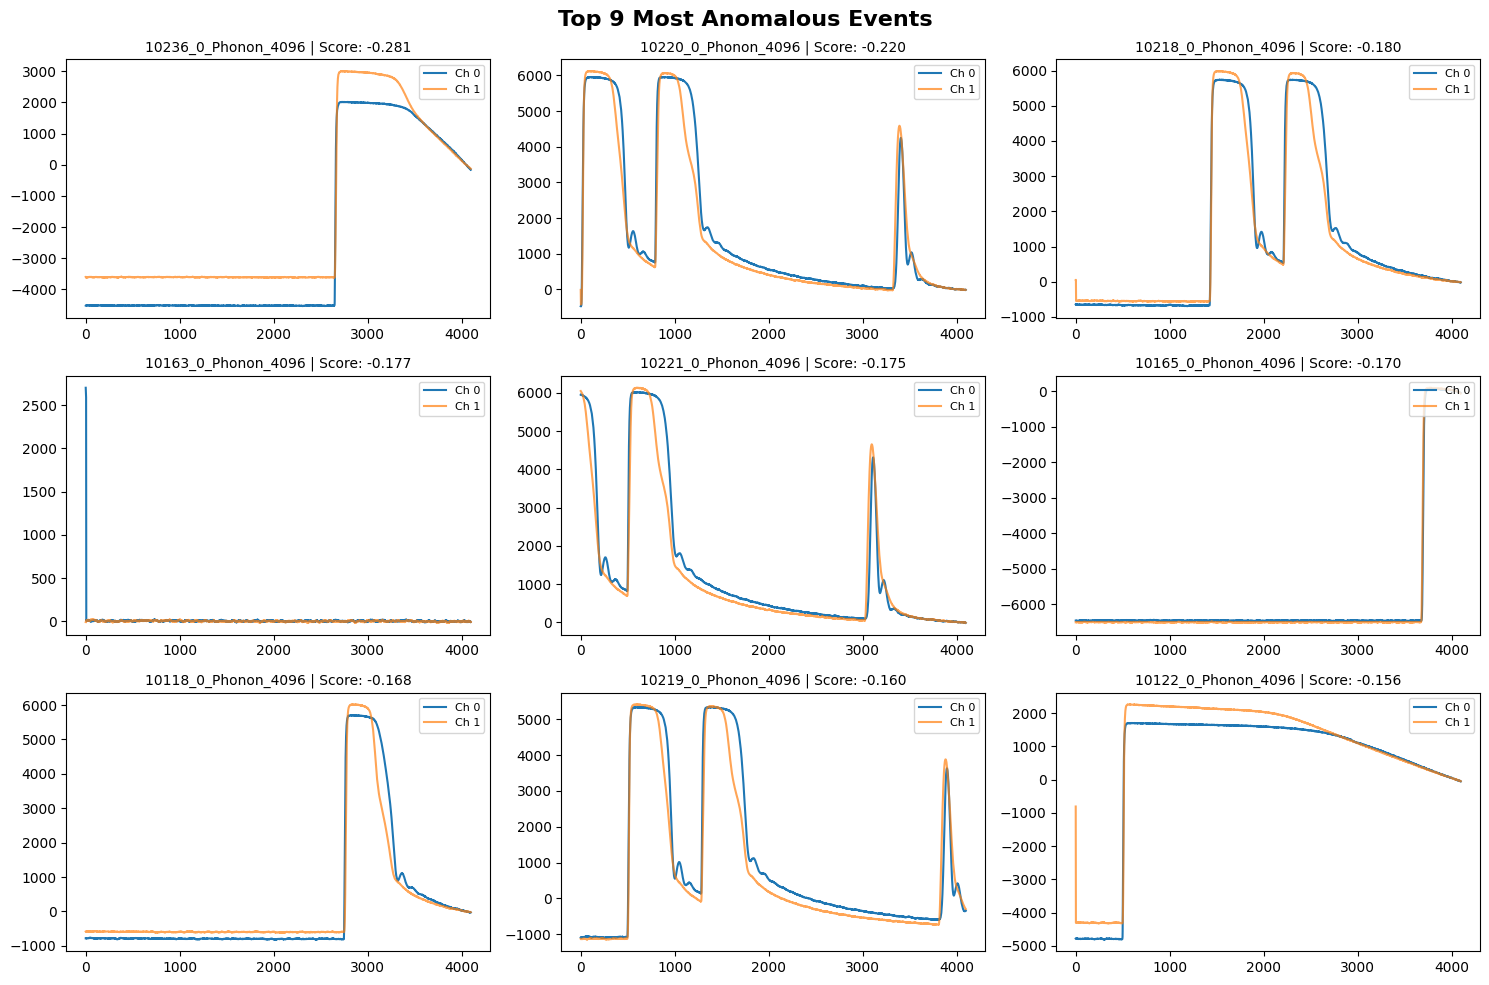

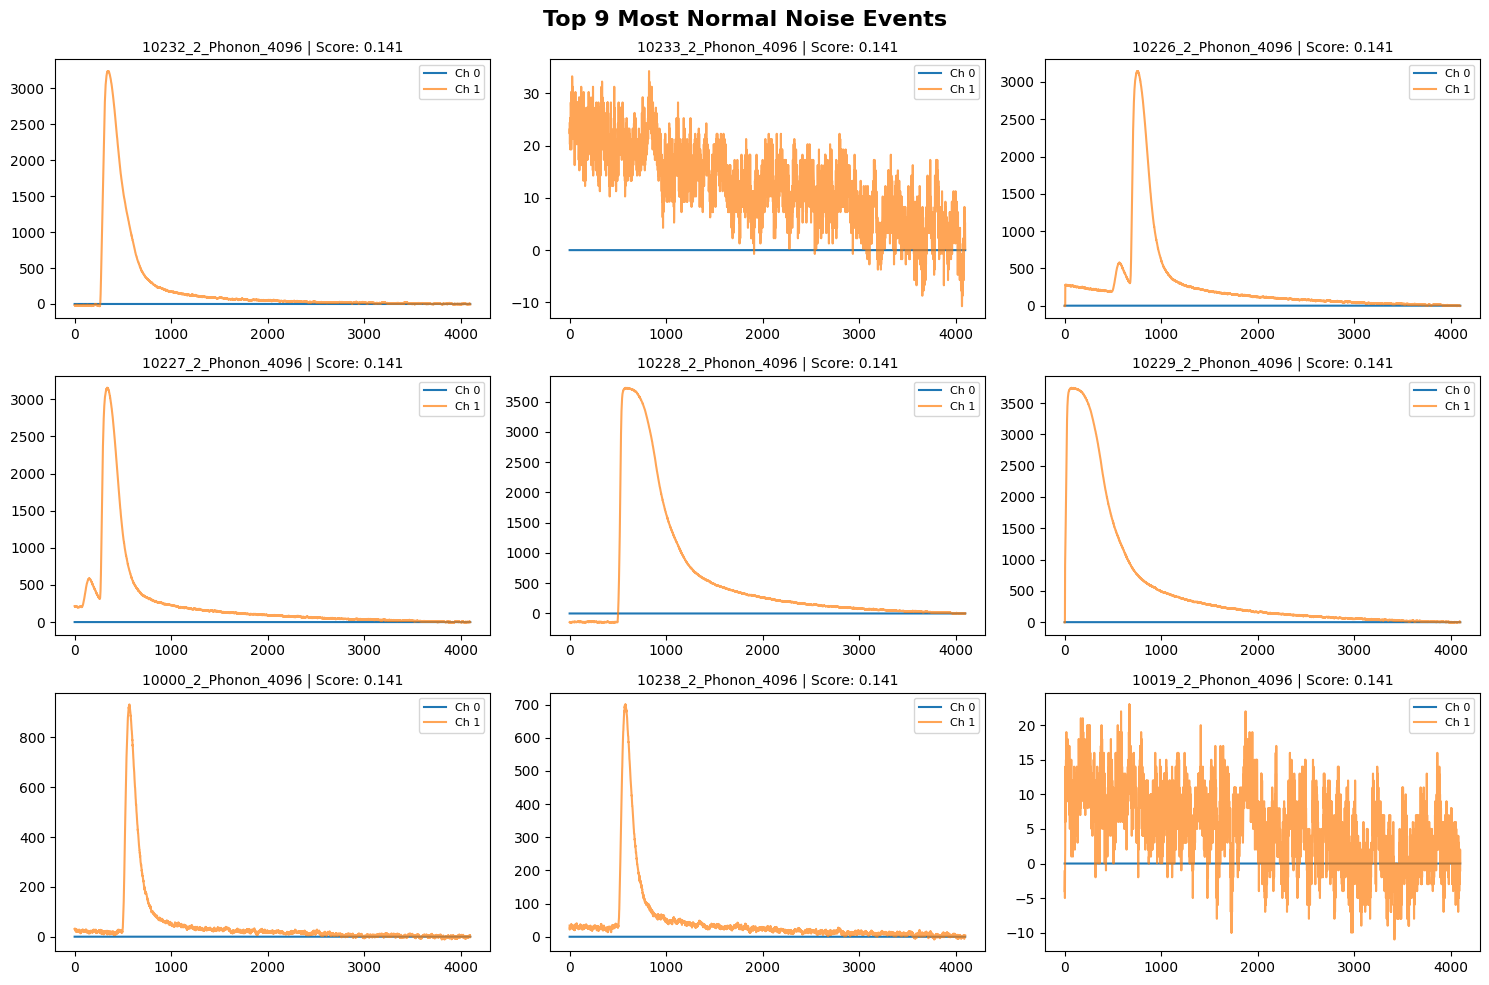

In [ ]:
#AI_generated v2 (handles error and allows visual comparison of multiple events)

from nsdf_dark_matter.idx import load_all_data
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# 1. Load Data
home_directory = Path.home()
cdms = load_all_data(str(home_directory) + '/idx/07180827_0000_F0002')
detector_ids = cdms.get_detector_ids()

# 2. Extract Features (with warning suppression)
features = []
valid_detector_ids = []

for det_id in detector_ids[:500]:
    try:
        channel_data = cdms.get_detector_channels(det_id)
        trace_0 = channel_data[0] - np.mean(channel_data[0][-100:])
        trace_1 = channel_data[1] - np.mean(channel_data[1][-100:])
        
        variance = np.var(trace_0)
        x_axis = np.arange(len(trace_0))
        slope, _ = np.polyfit(x_axis, trace_0, 1)
        
        # Suppress divide-by-zero warnings for dead channels
        with np.errstate(divide='ignore', invalid='ignore'):
            correlation = np.corrcoef(trace_0, trace_1)[0, 1]
            if np.isnan(correlation):
                correlation = 0.0 # Force a zero correlation if the math fails
                
        features.append([variance, slope, correlation])
        valid_detector_ids.append(det_id)
    except (IndexError, ValueError):
        continue

X = np.array(features)
valid_detector_ids = np.array(valid_detector_ids)

# 3. Train Model & Extract Continuous Scores
# When contamination is removed, it defaults to 'auto'
model = make_pipeline(StandardScaler(), IsolationForest(random_state=42))
model.fit(X)

# The decision_function returns a raw score for each event.
# Lower/negative scores are highly abnormal; higher/positive scores are normal.
scores = model.decision_function(X) 

# Sort indices from lowest score (most anomalous) to highest (most normal)
sorted_indices = np.argsort(scores)

# 4. Visualization Grid Function
def plot_grid(indices_to_plot, title_prefix):
    # Create a 3x3 grid of subplots sharing the same figure
    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))
    fig.suptitle(f"{title_prefix}", fontsize=16, fontweight='bold')
    
    # Iterate through the flat array of 9 axes and our selected event indices
    for ax, idx in zip(axes.flat, indices_to_plot):
        det_id = valid_detector_ids[idx]
        score = scores[idx]
        
        data = cdms.get_detector_channels(det_id)
        trace_0 = data[0] - np.mean(data[0][-100:])
        trace_1 = data[1] - np.mean(data[1][-100:])
        
        ax.plot(trace_0, label='Ch 0')
        ax.plot(trace_1, label='Ch 1', alpha=0.7)
        
        # Display the detector ID and the mathematical score
        ax.set_title(f"{det_id} | Score: {score:.3f}", fontsize=10)
        ax.legend(loc='upper right', fontsize=8)
    
    plt.tight_layout()
    plt.show()

# Generate the visual outputs
plot_grid(sorted_indices[:9], "Top 9 Most Anomalous Events")
plot_grid(sorted_indices[-9:], "Top 9 Most Normal Noise Events")

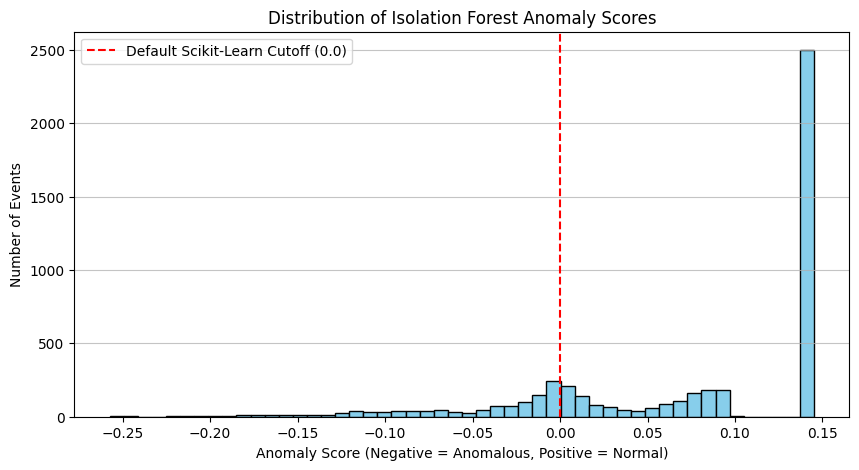

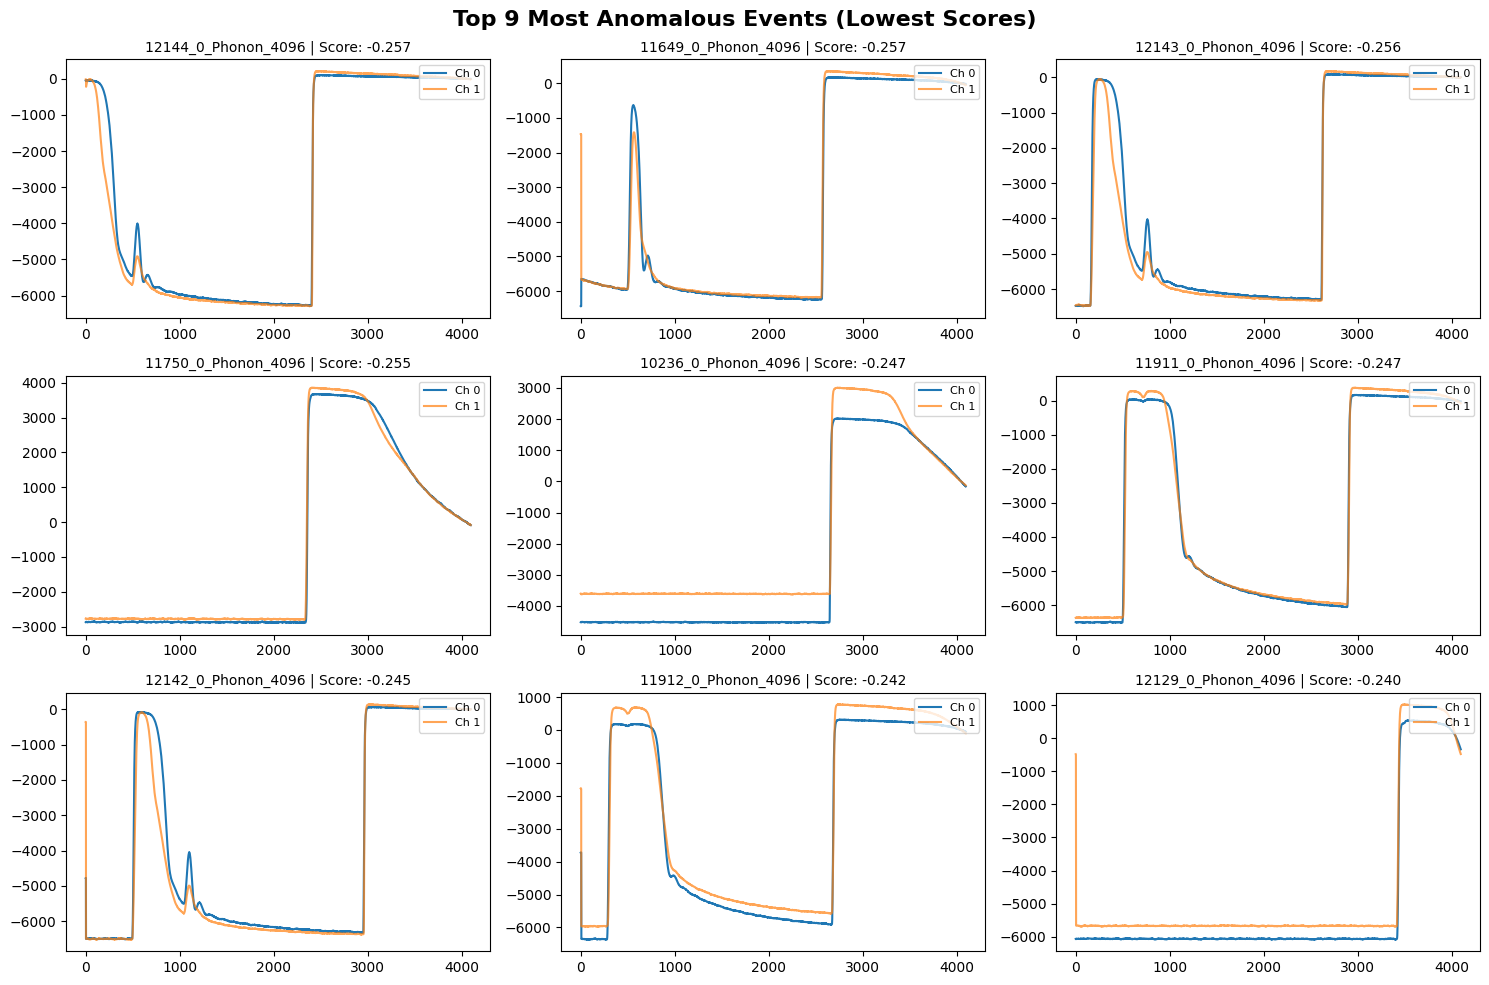

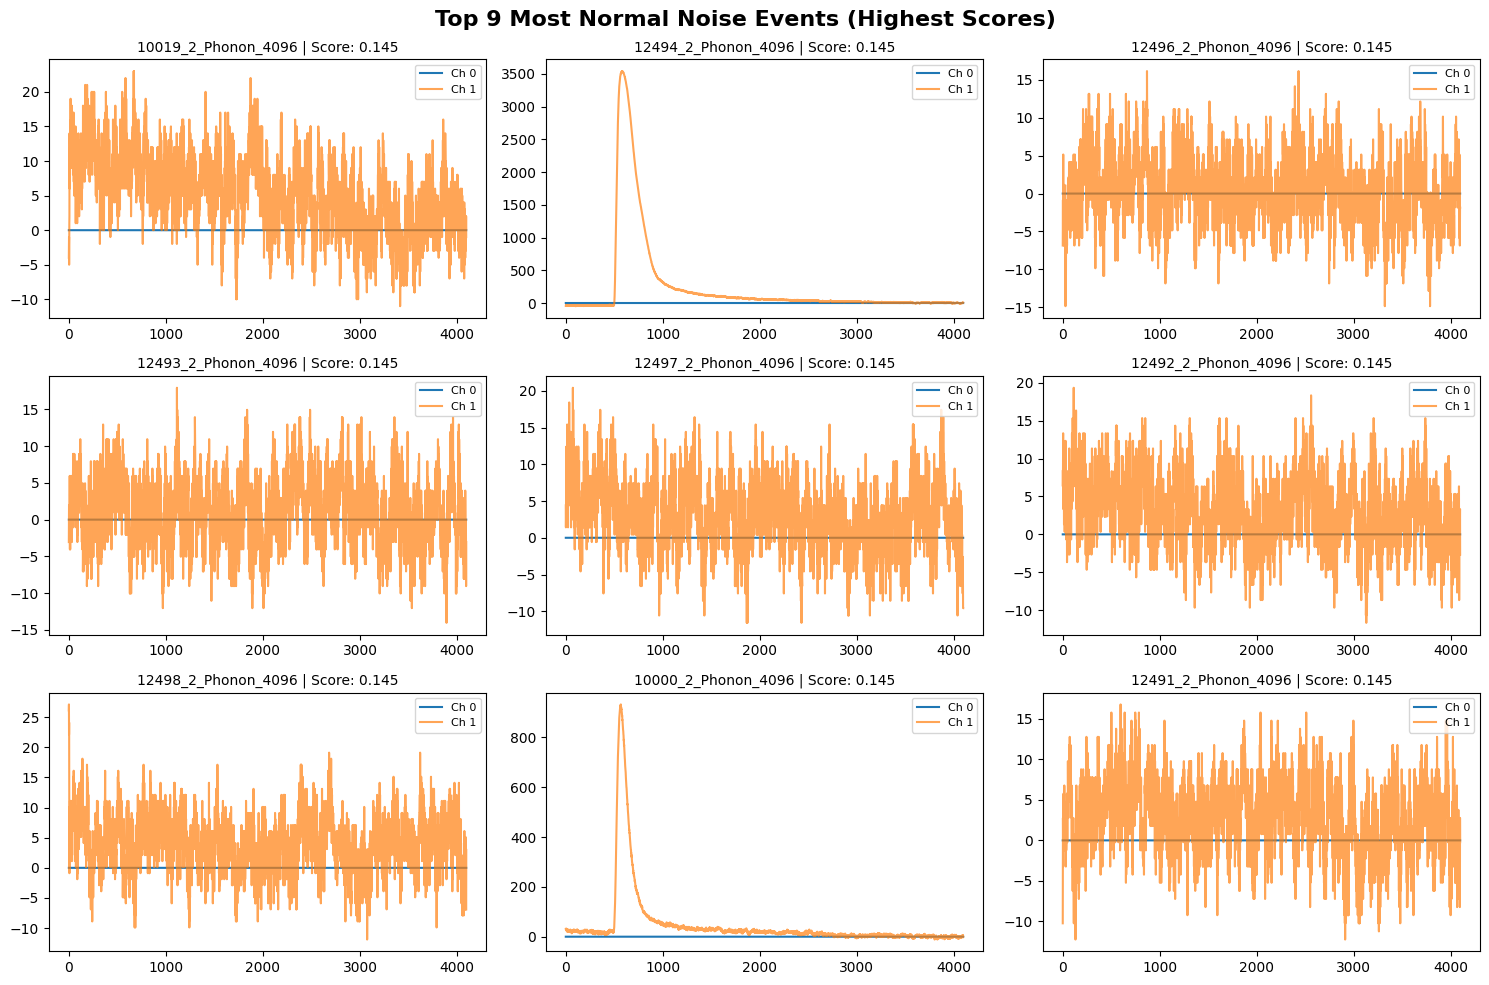

Total Anomalies found below 0.11: 2500
Total Normal events found above 0.11: 2500


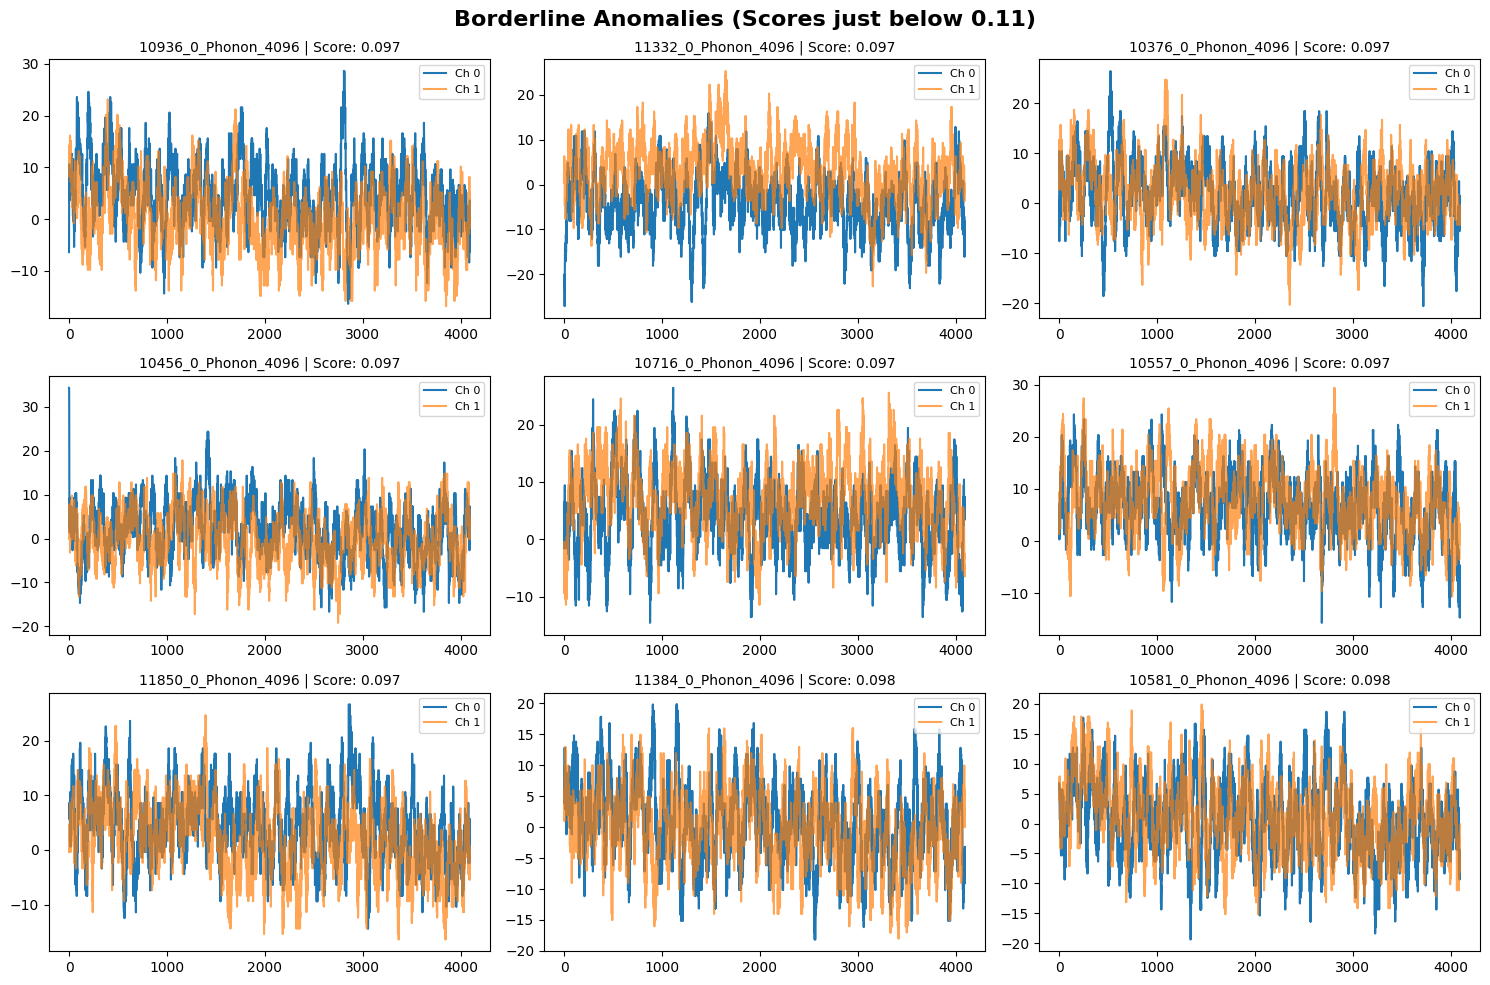

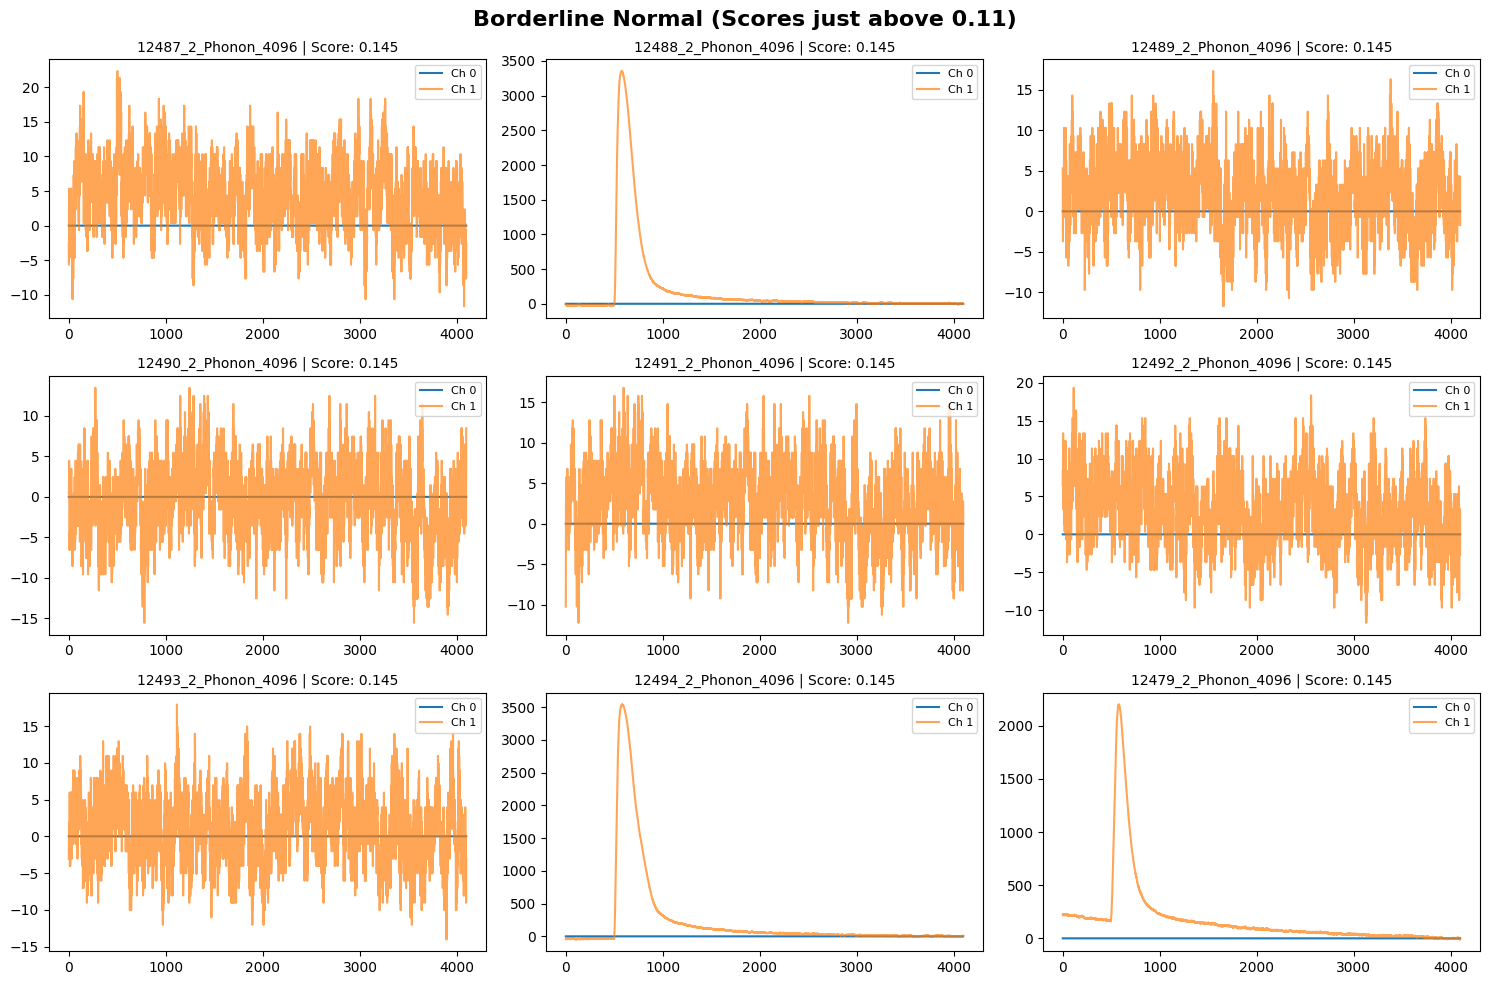

In [8]:
#AI-Generated v3 (histogram of categorizations added, as well as custom thrsh variable)

from nsdf_dark_matter.idx import load_all_data
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# 1. Load Data
home_directory = Path.home()
cdms = load_all_data(str(home_directory) + '/idx/07180827_0000_F0002')
detector_ids = cdms.get_detector_ids()

# 2. Extract Features
features = []
valid_detector_ids = []

for det_id in detector_ids[:5000]:
    try:
        channel_data = cdms.get_detector_channels(det_id)
        trace_0 = channel_data[0] - np.mean(channel_data[0][-100:])
        trace_1 = channel_data[1] - np.mean(channel_data[1][-100:])
        
        variance = np.var(trace_0)
        x_axis = np.arange(len(trace_0))
        slope, _ = np.polyfit(x_axis, trace_0, 1)
        
        with np.errstate(divide='ignore', invalid='ignore'):
            correlation = np.corrcoef(trace_0, trace_1)[0, 1]
            if np.isnan(correlation):
                correlation = 0.0
                
        features.append([variance, slope, correlation])
        valid_detector_ids.append(det_id)
    except (IndexError, ValueError):
        continue

X = np.array(features)
valid_detector_ids = np.array(valid_detector_ids)

# 3. Train Model & Extract Continuous Scores
# Using the default 'auto' contamination
model = make_pipeline(StandardScaler(), IsolationForest(random_state=42))
model.fit(X)

# The decision_function returns negative values for outliers and positive for inliers
scores = model.decision_function(X) 
sorted_indices = np.argsort(scores)

# 4. Plot Histogram of Anomaly Scores
plt.figure(figsize=(10, 5))
plt.hist(scores, bins=50, color='skyblue', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', label='Default Scikit-Learn Cutoff (0.0)')
plt.title("Distribution of Isolation Forest Anomaly Scores")
plt.xlabel("Anomaly Score (Negative = Anomalous, Positive = Normal)")
plt.ylabel("Number of Events")
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

# 5. Visualization Grid Function
def plot_grid(indices_to_plot, title_prefix):
    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))
    fig.suptitle(f"{title_prefix}", fontsize=16, fontweight='bold')
    
    for ax, idx in zip(axes.flat, indices_to_plot):
        det_id = valid_detector_ids[idx]
        score = scores[idx]
        
        data = cdms.get_detector_channels(det_id)
        trace_0 = data[0] - np.mean(data[0][-100:])
        trace_1 = data[1] - np.mean(data[1][-100:])
        
        ax.plot(trace_0, label='Ch 0')
        ax.plot(trace_1, label='Ch 1', alpha=0.7)
        ax.set_title(f"{det_id} | Score: {score:.3f}", fontsize=10)
        ax.legend(loc='upper right', fontsize=8)
    
    plt.tight_layout()
    plt.show()

# Generate the visual outputs for the extremes
plot_grid(sorted_indices[:9], "Top 9 Most Anomalous Events (Lowest Scores)")
plot_grid(sorted_indices[-9:], "Top 9 Most Normal Noise Events (Highest Scores)")


# Define the custom threshold determined from the histogram
custom_threshold = 0.11

# Extract events strictly below the threshold (Anomalies)
anomaly_indices = np.where(scores < custom_threshold)[0]
# Sort anomalies by score and isolate the 9 closest to the 0.1 cutoff
borderline_anomalies = anomaly_indices[np.argsort(scores[anomaly_indices])][-9:]

# Extract events strictly above the threshold (Normal Noise)
normal_indices = np.where(scores >= custom_threshold)[0]
# Sort normal events by score and isolate the 9 closest to the 0.1 cutoff
borderline_normals = normal_indices[np.argsort(scores[normal_indices])][:9]

# Output counts for context
print(f"Total Anomalies found below {custom_threshold}: {len(anomaly_indices)}")
print(f"Total Normal events found above {custom_threshold}: {len(normal_indices)}")

# Generate visualization grids for the borderline cases
plot_grid(borderline_anomalies, f"Borderline Anomalies (Scores just below {custom_threshold})")
plot_grid(borderline_normals, f"Borderline Normal (Scores just above {custom_threshold})")

9/21 Notes
Optimal Filter
Our energy histogram (data recorded) peaks as you go toward 0, but that area of the histogram is where we need to look for dark matter interactions (low energy). In order to recover some of that space, we can move into Fourier space and analyze as a function of frequency instead of time. This clearly marks regular noise patterns that were indistinguishable in time space. In fourier space we can then heavily penalize those certain frequencies and then transofmr back to time space. Then we will have a new enrgy histogram with recovered area at low energies.

- I'm running into interesting areas where I need to apply math to physics, and sometimes the results aren't sensible. This includes imaginary numbers, and integrating the fourier transform from -inf to inf leads to negative frequencies, and in general I want to better understand what this whole situation looks like. How do the tools I have interact in order to describe and extract information from reality?


Big T is overall sample window 